## Analytical solution for graph heat diffusion w/ boundary conditions

Constraints:
- constant temperature for heat source (CV) & heat sink (PV)
- tempetature == 0 at tissue boundary ($\dfrac{\partial^2 u}{\partial S^2} = 0$)

Solve by [Grady & Schwartz (2003)](https://open.bu.edu/handle/2144/1911)

In [5]:
import os
import sys
import time
import tifffile
import numpy as np
import pandas as pd
import networkx as nx

from scipy.sparse import linalg
from scipy import ndimage as ndi
from skimage import draw
from skimage.morphology import binary_dilation
from skimage.segmentation import find_boundaries

In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib import rcParams

rcParams.update({'font.size': 10})
rcParams.update({'figure.dpi': 300})
rcParams.update({'savefig.dpi': 300})

import warnings
warnings.filterwarnings('ignore')

In [38]:
sys.path.append('../')
import zonation

In [51]:
from importlib import reload
reload(zonation)

<module 'zonation' from '/home/yinuo/Desktop/azizi_lab/IMS/notebooks/../zonation.py'>

### 2D simulation

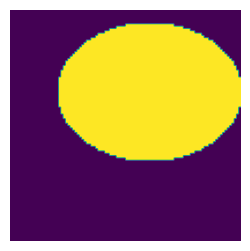

In [4]:
# Generate random ellipse as ROI
roi = np.zeros((100, 100))
rr, cc = draw.ellipse(r=35, c=60, r_radius=30, c_radius=40, shape=roi.shape)
roi[rr, cc] = 1

del rr, cc

plt.figure(dpi=100)
plt.imshow(roi)
plt.axis('off')
plt.show()

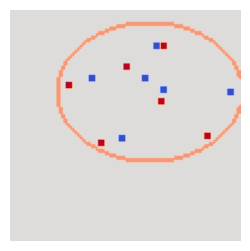

In [5]:
# Assign random CV & PV pts
def sample_stable_coords(roi, nsample):
    """Sample coords for CV & PV from roi coords"""
    cv_img = np.zeros_like(roi).astype(np.float64)
    pv_img = np.zeros_like(cv_img)
    coords = np.array(np.nonzero(roi))
    indices = np.random.randint(coords.shape[1], size=nsample)

    cv_coords = tuple(coords[:, indices[:nsample//2]])
    pv_coords = tuple(coords[:, indices[nsample//2:]])

    cv_img[cv_coords] = 1
    cv_img = binary_dilation(cv_img, np.ones((3,3)))
    pv_img[pv_coords] = 1
    pv_img = binary_dilation(pv_img, np.ones((3,3))) * -1    
    return cv_img + pv_img

sim_img = sample_stable_coords(roi, 12).astype('float64')
plt.figure(dpi=100)
plt.imshow(sim_img + find_boundaries(roi)*0.5, cmap='coolwarm')
plt.axis('off')
plt.show()

In [6]:
# Convert sim. img to graph with 4-connected compoments adj(i) = {(i, j+1), (i, j-1), (i+1, j), (i-1, j)}
def create_graph(roi):
    """
    Convert combinatory graph from ROI pixels
    Code Referenced from: https://stackoverflow.com/questions/63653267/how-to-create-a-graph-with-an-images-pixel
    """
    # Horizontal edge
    hx, hy =  np.nonzero(np.logical_and(roi[1:] == 1, roi[:-1] == 1)) #horizontal edge start positions
    h_units = np.array([hx, hy]).T
    h_starts = [tuple(n) for n in h_units]
    h_ends = [tuple(n) for n in h_units + (1, 0)] #end positions = start positions shifted by vector (1,0)
    horizontal_edges = zip(h_starts, h_ends)

    # Vertical edge
    vx, vy = np.nonzero(np.logical_and(roi[:,1:] == 1,  roi[:,:-1] == 1)) #vertical edge start positions
    v_units = np.array([vx, vy]).T
    v_starts = [tuple(n) for n in v_units]
    v_ends = [tuple(n) for n in v_units + (0, 1)] #end positions = start positions shifted by vector (0,1)
    vertical_edges = zip(v_starts, v_ends)

    # Create graph
    G = nx.Graph()
    G.add_edges_from(horizontal_edges)
    G.add_edges_from(vertical_edges)

    pos_dict = dict(zip(G.nodes(), G.nodes())) # node name -> coord
    
    return G, pos_dict


In [146]:
G, pos_dict = create_graph(roi)

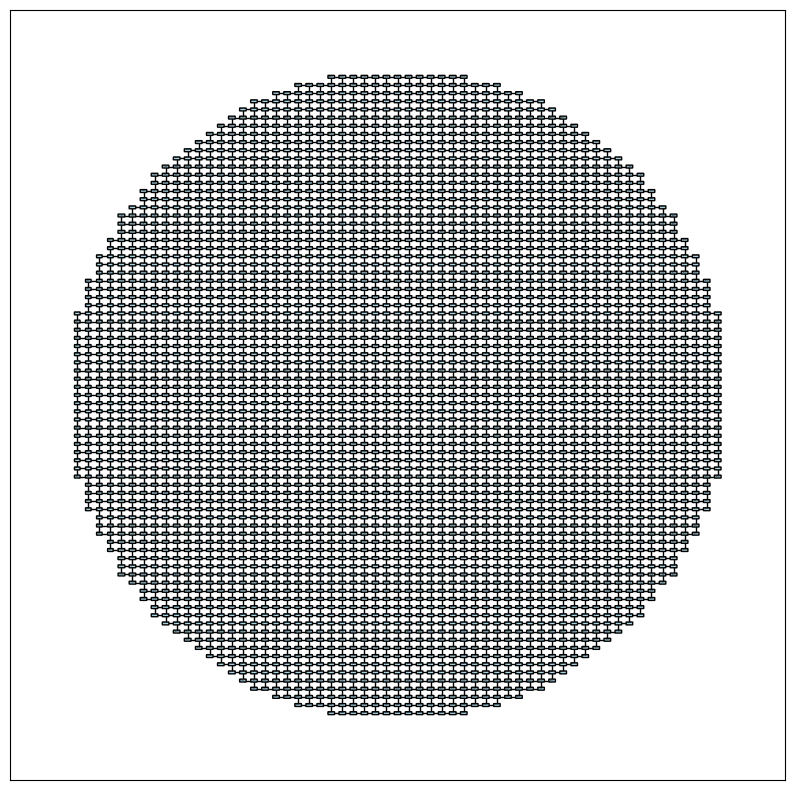

In [10]:
# Visualize graph
plt.figure(figsize=(10, 10), dpi=100)
nx.draw_networkx(G, pos_dict, with_labels=False, node_size=0)
labels={node: f'({node[0]},{node[1]})' for node in G.nodes()}
nx.draw_networkx_labels(G, pos_dict, labels, font_size=1, font_family='serif', font_weight='bold', bbox = dict(fc='lightblue', ec="black", boxstyle="round", lw=1))
plt.show()

In [101]:
cv_indices = {tuple(idx) for idx in np.array(np.where(sim_img == 1)).T}
pv_indices = {tuple(idx) for idx in np.array(np.where(sim_img == -1)).T}

In [148]:
add_graph_props(G, cv_indices, pv_indices)

#### Create permuted Laplacian Matrix

$L' = \begin{pmatrix} L_{b} & R \\ R^T & L_{i} \end{pmatrix}$

In [149]:
def compute_interior_temp(G, debug=False):
    """
    Compute temperature of "interior" nodes based on Harmonic interpolation solution (Grady & Schwartz, 2003)
    """
    # Constructed permuted Laplacian Matrix L => {L_b, L_i, R, R^T}
    bound_nodes = [
        n for n, v in G.nodes.items()
        if 'bound' in v
    ]

    interior_nodes = [
        n for n, v in G.nodes.items()
        if 'bound' not in v
    ]

    n_bound = len(bound_nodes)
    perm_node_orders = bound_nodes + interior_nodes
    if debug:
        assert len(G) == len(perm_node_orders)

    L = nx.laplacian_matrix(G, nodelist=perm_node_orders).A
    L_i = L[n_bound:, n_bound:]
    R = L[:n_bound, n_bound:]

    # Validate permuted nodes' in-degree have the correct order [d(bound), d(interior)]
    if debug:
        diag = np.diag(L)
        for i, n in enumerate(perm_node_orders):
            assert G.degree[n] == diag[i]

    # Compute interior temperature u(i) from L & u(b)
    u_b = np.asarray([G.nodes[n]['t'] for n in bound_nodes])
    u_i = linalg.cg(A=L_i, b=-R.T@u_b)

    if isinstance(u_i, tuple):
        u_i = u_i[0]
    
    return u_i, tuple(np.array(interior_nodes).T)  # 2 x N tuple


# Assign init. temp. & ROI boundary as graph properties
def add_graph_props(G, cv_nodes, pv_nodes):
    for n in G:
        if n in cv_nodes:
            G.nodes[n]['t'] = 1
            G.nodes[n]['bound'] = True
        elif n in pv_nodes:
            G.nodes[n]['t'] = -1
            G.nodes[n]['bound'] = True
        else:
            G.nodes[n]['t'] = 0
            if G.degree[n] < 4:
                G.nodes[n]['bound'] = True
    return None


def assign_zone_diff(img, coords, u):
    """
    Assign steady-state sol. of the diffused pixel values back to the image
    """
    assert len(coords[0]) == len(u), 'Different coords & tempeerature lengths'
    diff_img = img.copy()
    diff_img[coords] = u
    
    return diff_img


In [150]:
u_i, interior_nodes = compute_interior_temp(G)
diff_img = assign_zone_diff(sim_img, interior_nodes, u_i)

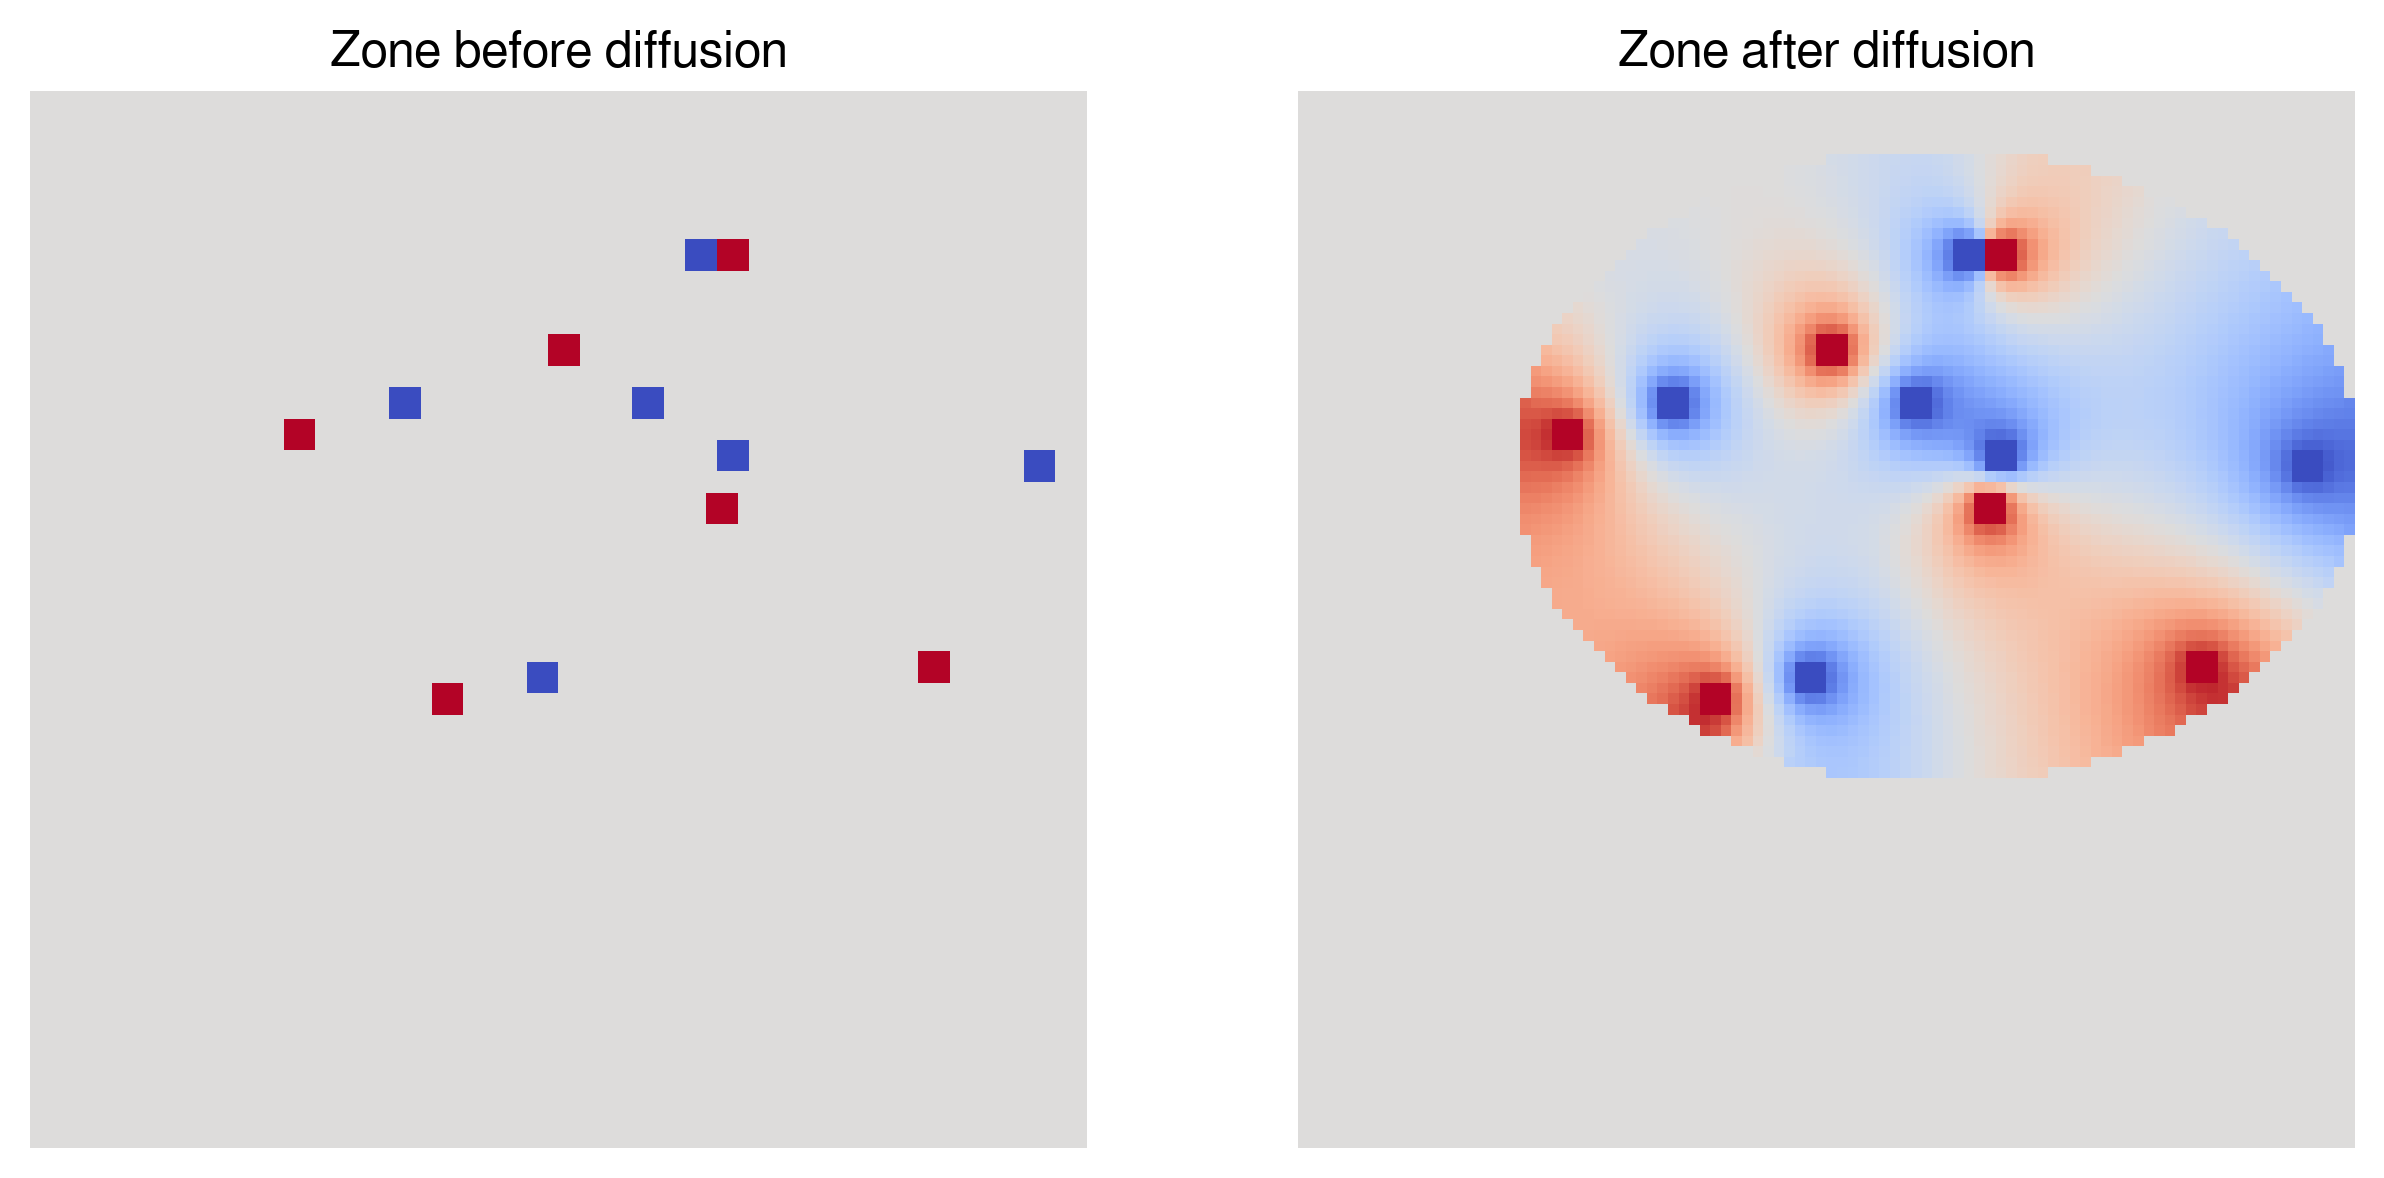

In [152]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(sim_img,  cmap='coolwarm')
ax1.set_title("Zone before diffusion")
ax1.axis('off')

ax2.imshow(diff_img, cmap='coolwarm')
ax2.set_title('Zone after diffusion')
ax2.axis('off')

plt.show()

In [ ]:
plt.figure(figsize=(5, 2))
plt.hist(diff_img[roi == 1], bins=30)
plt.suptitle('Temperature distribution')
plt.show()

### Real Liver slide

#### Aubrianna's Liver ROI

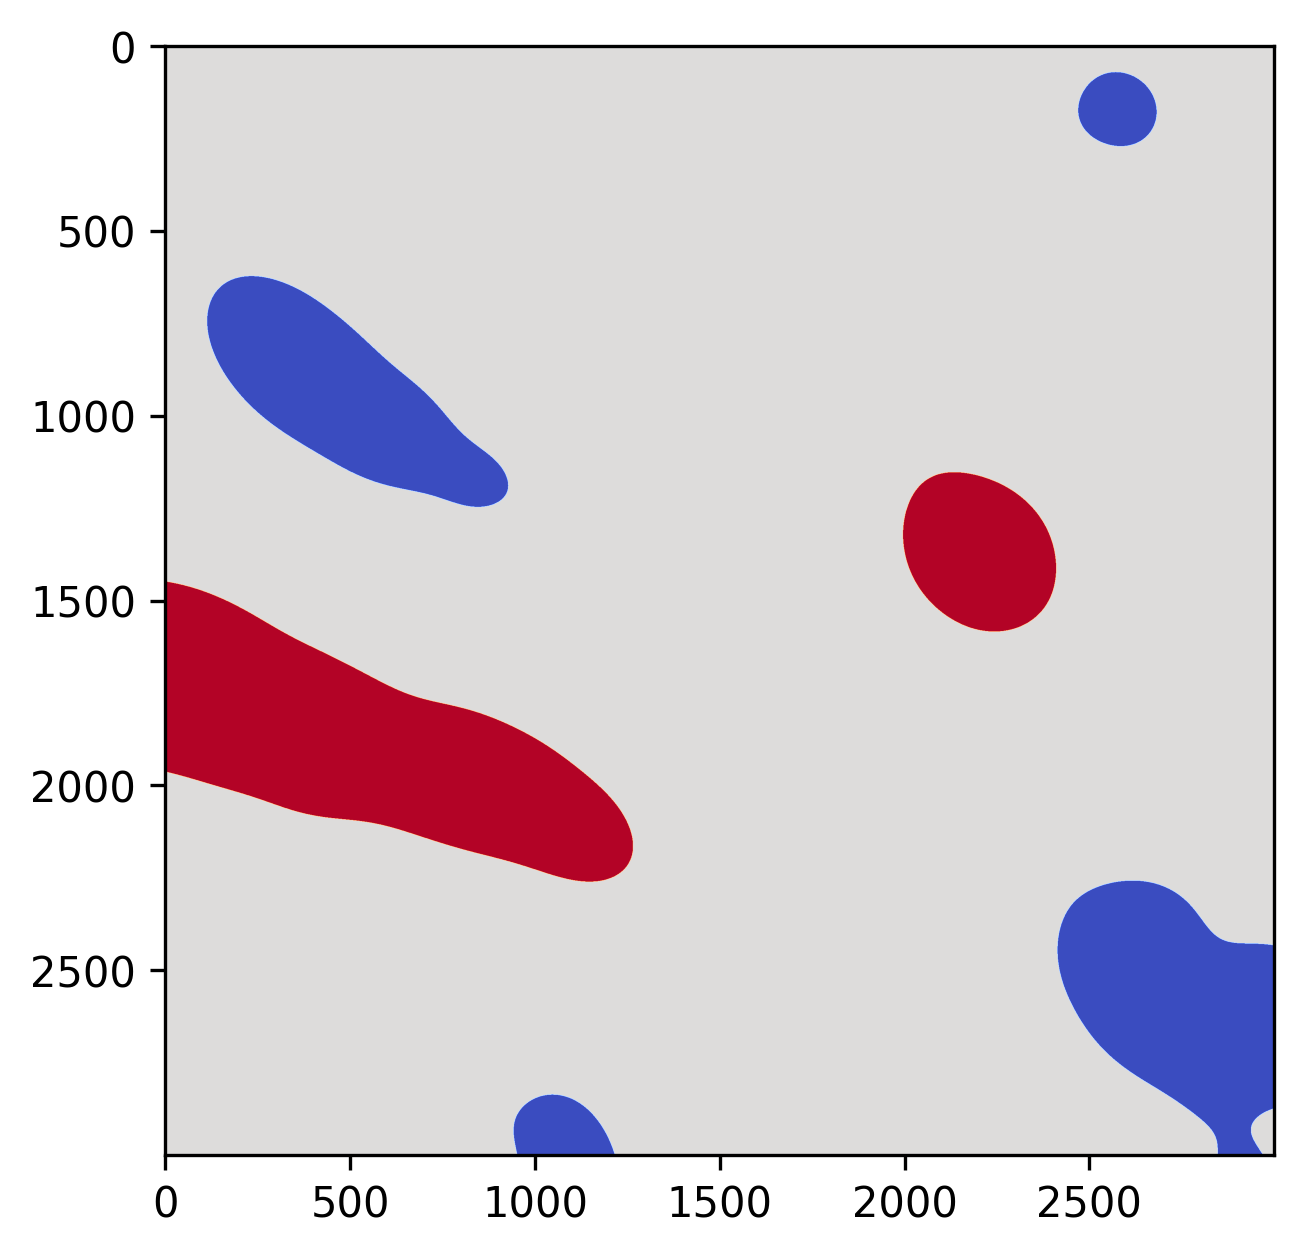

In [8]:
mask = tifffile.imread('../data/cycif/pilot_fov/mini-ibex-img_zonation.tif').astype(np.int32)
mask[mask == 1] = -1
mask[mask == 2] = 1

plt.figure()
plt.imshow(mask, cmap='coolwarm')
plt.show()

In [9]:
cv_indices = {tuple(idx) for idx in np.array(np.where(mask == 1)).T}
pv_indices = {tuple(idx) for idx in np.array(np.where(mask == -1)).T}

In [29]:
t0 = time.perf_counter()

G = zonation.create_graph(np.ones_like(mask))
zonation.add_graph_props(G, cv_indices, pv_indices)
u_i, interior_nodes = zonation.compute_interior_temp(G)
u = zonation.assign_diffusion_temp(u_i, 
                                   interior_nodes,
                                   np.where(mask == 1),
                                   np.where(mask == -1), 
                                   mask.shape)

t1 = time.perf_counter()
print('Heat diffusion for dim [{0}x{1}] takes {2}s'.format(mask.shape[0], mask.shape[1], t1-t0))
del G, u_i, interior_nodes

In [12]:
tifffile.imsave('data/cycif/pilot_fov/mini-ibex-img_gradients_linalg.tif', u)

Binning 10 lobule layers (PV -> CV: 1,..., 10) from the inferred diffusion temperature(gradients):

In [41]:
lobule_layers = zonation.discretize_temp(u,
                                         roi=(mask == 0).astype(np.uint8),
                                         cv_coords=np.where(mask == 1),
                                         n_layers=10,
                                         return_border=True)


In [ ]:
tifffile.imsave('data/cycif/pilot_fov/mini-ibex-img_lobule_layers_linalg.tif', lobule_layers)

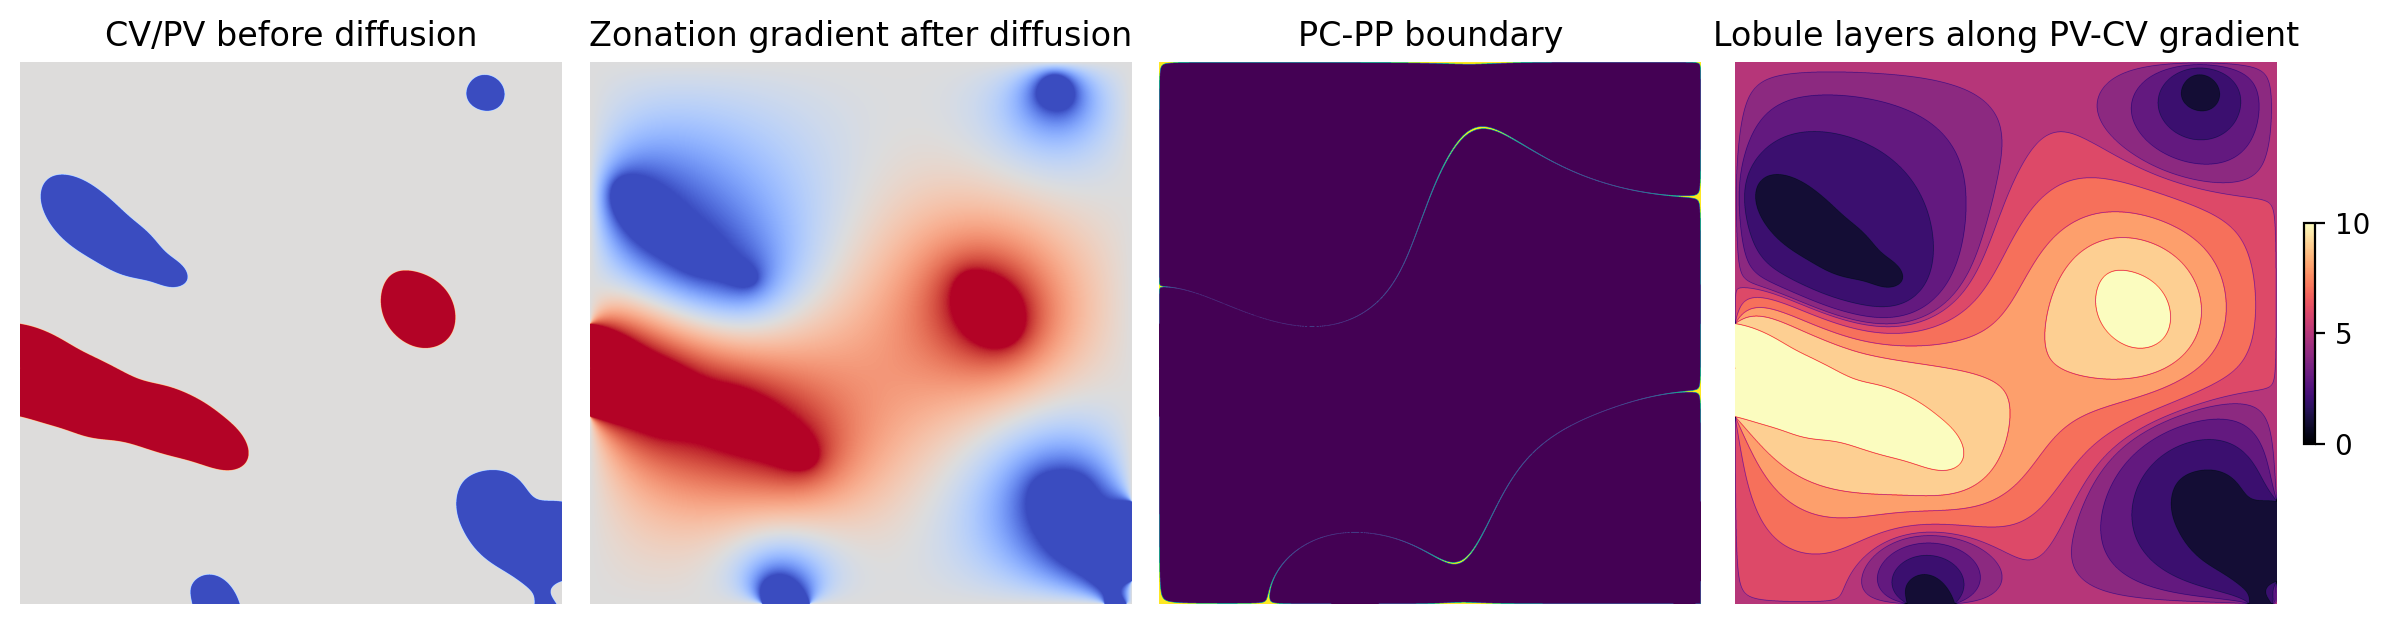

In [42]:
# Visualize PC-PP border

pc_pp_boundary = np.isclose(u, 0, atol=1e-3)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(12, 3), constrained_layout=True, dpi=200)
ax1.imshow(mask,  cmap='coolwarm')
ax1.set_title("CV/PV before diffusion")
ax1.axis('off')

ax2.imshow(u, cmap='coolwarm')
ax2.set_title('Zonation gradient after diffusion')
ax2.axis('off')

ax3.imshow(pc_pp_boundary)
ax3.set_title('PC-PP boundary')
ax3.axis('off')

im = ax4.imshow(lobule_layers, cmap='magma')
fig.colorbar(im, ax=ax4, fraction=0.02)
ax4.set_title('Lobule layers along PV-CV gradient')
ax4.axis('off')

plt.show()

#### Presha's Liver slide

In [43]:
from skimage.exposure import rescale_intensity
from skimage.filters import gaussian, threshold_otsu

In [44]:
def remove_holes(roi, min_area=20000):
    """
    Remove holes & FP lslands in binary ROI mask
    """
    roi_filtered = roi.copy().astype(np.uint8)
    roi_labeled, n_features = ndi.label(roi)
    
    for i in range(1, n_features+1):
        if (roi_labeled == i).sum() < min_area:
            roi_filtered[roi_labeled == i] = 0
            
    return ndi.binary_fill_holes(roi_filtered)

In [47]:
# # Load ROI & CV/PV mask
dapi = tifffile.imread('../data/cycif/pilot_fov/Layer_overlaid_ROI.ome.tif')[0]
dapi = rescale_intensity(gaussian(dapi, sigma=10), out_range=(0, 1))
roi_thld = threshold_otsu(dapi)
roi = remove_holes(dapi > roi_thld)
roi[:200, :] = 0 # Heuristically remove fluorescence artifacts
del roi_thld

mask = tifffile.imread('../data/cycif/pilot_fov/ROI_zone_masks.ome.tif').astype(np.int32)
mask[mask == 1] = -1 # PV
mask[mask == 2] = 1  # CV
mask[roi == 0] = 0  # Filter with tissue ROI

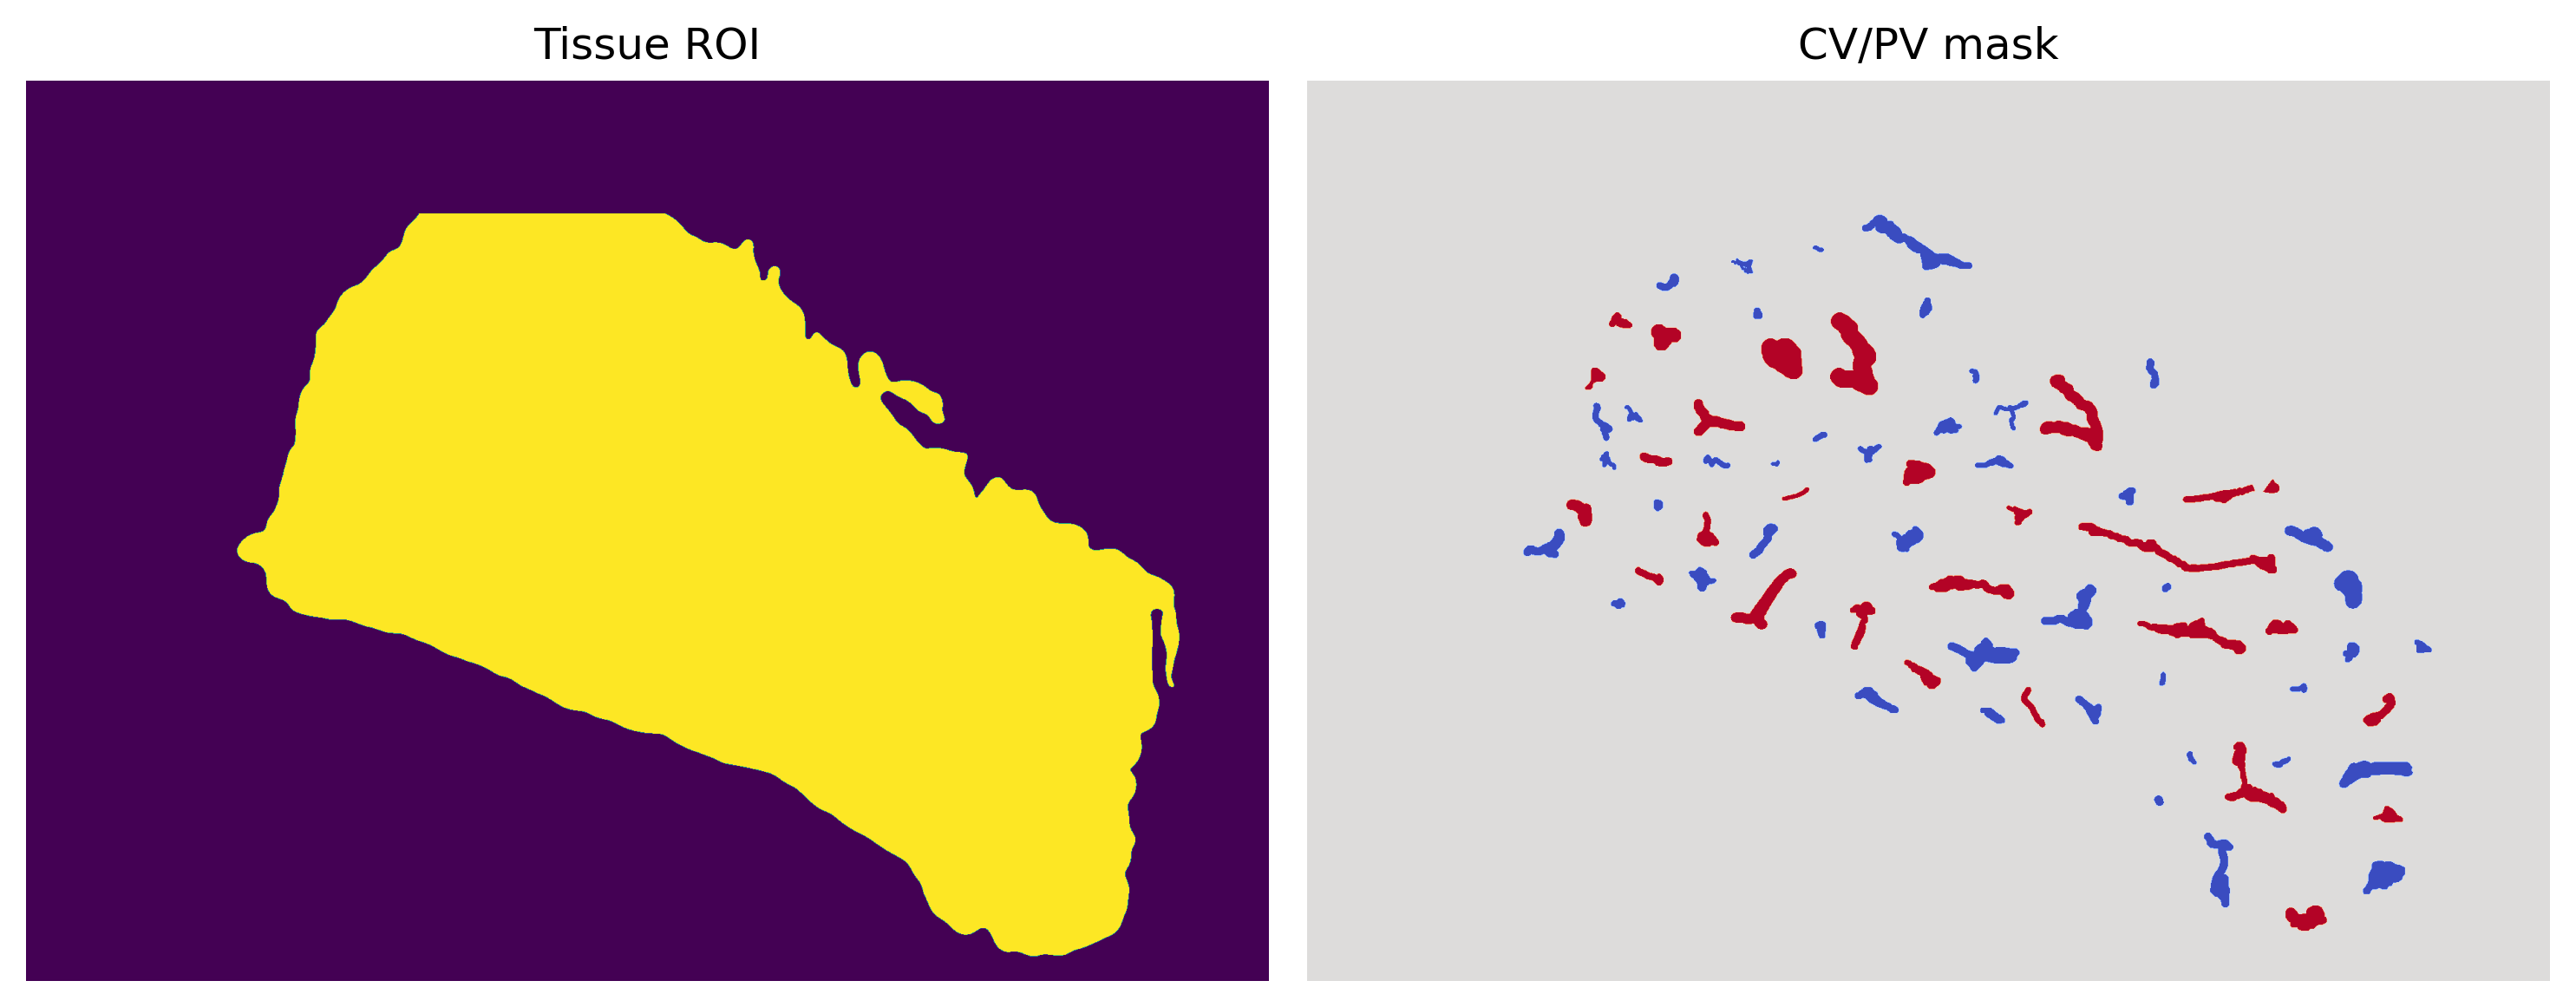

In [48]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(roi)
ax1.set_title('Tissue ROI')
ax1.axis('off')

ax2.imshow(mask, cmap='coolwarm')
ax2.set_title('CV/PV mask')
ax2.axis('off')

plt.tight_layout()
plt.show()

In [49]:
cv_indices = {tuple(idx) for idx in np.array(np.where(mask == 1)).T}
pv_indices = {tuple(idx) for idx in np.array(np.where(mask == -1)).T}

In [52]:
#t0 = time.perf_counter()

#G = zonation.create_graph(roi=roi)
#zonation.add_graph_props(G, cv_indices, pv_indices)
#u_i, interior_nodes = zonation.compute_interior_temp(G)
u = zonation.assign_diffusion_temp(u_i, 
                                   interior_nodes,
                                   np.where(mask == 1),
                                   np.where(mask == -1), 
                                   mask.shape)

#t1 = time.perf_counter()
#print('Heat diffusion for dim [{0}x{1}] takes {2}s'.format(mask.shape[0], mask.shape[1], t1-t0))
del G, u_i, interior_nodes

In [53]:
tifffile.imsave('data/cycif/pilot_fov/ROI_gradients_linalg.tif', u)

Binning 10 lobule layers from trajectory (gradients):

In [63]:
lobule_layers = zonation.discretize_temp(u,
                                         roi=roi,
                                         cv_coords=np.where(mask == 1),
                                         n_layers=10,
                                         return_border=True)

In [79]:
tifffile.imsave('data/cycif/pilot_fov/ROI_lobule_layers_linalg.tif', lobule_layers)

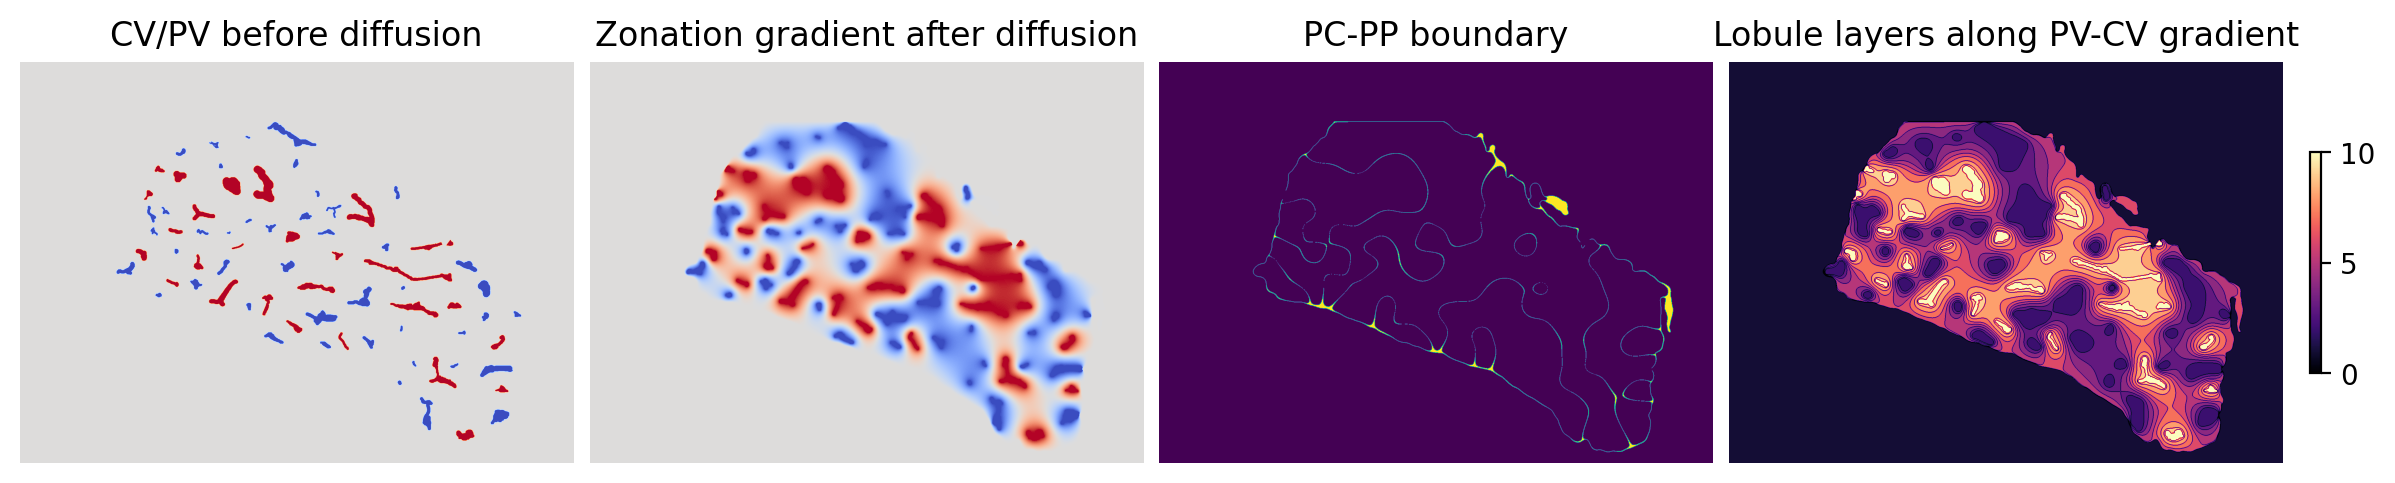

In [65]:
# PC-PP boundary
pc_pp_boundary = np.isclose(u, 0, atol=1e-2)
pc_pp_boundary[roi == 0] = 0

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(12, 3), constrained_layout=True, dpi=200)
ax1.imshow(mask,  cmap='coolwarm')
ax1.set_title("CV/PV before diffusion")
ax1.axis('off')

ax2.imshow(u, cmap='coolwarm')
ax2.set_title('Zonation gradient after diffusion')
ax2.axis('off')

ax3.imshow(pc_pp_boundary)
ax3.set_title('PC-PP boundary')
ax3.axis('off')

im = ax4.imshow(lobule_layers, cmap='magma')
fig.colorbar(im, ax=ax4, fraction=0.02)
ax4.set_title('Lobule layers along PV-CV gradient')
ax4.axis('off')

plt.show()

---